In [109]:
import os
from functools import partial
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from yaml import FullLoader

from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.engine import DefaultPredictor
from detectron2.structures import BoxMode
from detectron2.utils.visualizer import Visualizer

In [110]:
image_path = "/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC01026_tile47.png"

In [111]:
root_image_dir = Path(
    "/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images"
)

# find all pngs in root image dir, but not in subdirectories
img_paths = [f for f in root_image_dir.iterdir() if f.suffix == ".png" and f.is_file()]
img_paths

[PosixPath('/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC00949_tile33.png'),
 PosixPath('/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC01026_tile47.png'),
 PosixPath('/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC00949_tile3.png'),
 PosixPath('/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC00949_tile8.png'),
 PosixPath('/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC09874_tile16.png'),
 PosixPath('/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC01033_tile6.png'),
 PosixPath('/home/taheera.ahmed/code/reindeerdrone/assets/gradio_example_images/DSC01033_tile33.png')]

# Detectron 2


In [112]:
def get_reindeer_dicts(tile_dir, annotations):
    dataset_dicts = []
    for idx, anno in enumerate(annotations):
        record = {}
        filename = os.path.join(tile_dir, f"{anno['image_id']}.png")
        height, width = cv2.imread(filename).shape[:2]

        record["file_name"] = filename
        record["image_id"] = idx
        record["height"] = height
        record["width"] = width

        objs = []
        for bbox in anno["annotations"]:
            obj = {
                "bbox": bbox["bbox"],
                "bbox_mode": BoxMode.XYWH_ABS,
                "category_id": bbox["category_id"],
            }
            objs.append(obj)
        record["annotations"] = objs
        dataset_dicts.append(record)
    return dataset_dicts


In [113]:
dataset_name = "reindeer_test"

current_dir = Path().resolve()
config_path = current_dir.parent / "src" / "detectron2" / "configs" / "config.yaml"


with open(config_path) as f:
    cfgP = yaml.load(f, Loader=FullLoader)

img_dir = cfgP["TILE_TEST_FOLDER_PATH"]
annotations_file = cfgP["TILE_TEST_ANNOTATION_PATH"]
model_weights = "/home/taheera.ahmed/code/reindeerdrone/outputs/detectron2/00_default_augs/model_final.pth"


In [114]:
if dataset_name not in DatasetCatalog.list():
    DatasetCatalog.register(
        dataset_name,
        partial(get_reindeer_dicts, img_dir=img_dir, annotations_file=annotations_file),
    )
    MetadataCatalog.get(dataset_name).set(thing_classes=["Adult", "Calf"])

# setting up the model configuration
cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2
cfg.MODEL.WEIGHTS = model_weights
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
cfg.DATASETS.TEST = (dataset_name,)

predictor = DefaultPredictor(cfg)

In [115]:
def predict_detectron2(img_paths, predictor):
    detectron2_output_imgs = []
    for img_path in img_paths:
        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        outputs = predictor(image)

        # opencv uses BGR by default, but the visualizer expects RGB, so we reverse the channels
        v = Visualizer(image, MetadataCatalog.get(cfg.DATASETS.TEST[0]), scale=1.2)
        v = v.draw_instance_predictions(outputs["instances"].to("cpu"))

        detectron2_output_image = v.get_image()
        detectron2_output_imgs.append(detectron2_output_image)
    return detectron2_output_imgs


detectron2_output_imgs = predict_detectron2(img_paths, predictor)

# YOLOv11


In [116]:
# load yolo model
from ultralytics import YOLO

yolo_weights = "/home/taheera.ahmed/code/reindeerdrone/outputs/2025-02-25/16-16-26/training_logs/train/weights/best.pt"
model = YOLO(yolo_weights)
results = model(source=img_paths, imgsz=1024)


0: 1024x1024 (no detections), 8.5ms
1: 1024x1024 2 Adults, 1 Calf, 8.5ms
2: 1024x1024 (no detections), 8.5ms
3: 1024x1024 (no detections), 8.5ms
4: 1024x1024 1 Adult, 8.5ms
5: 1024x1024 (no detections), 8.5ms
6: 1024x1024 (no detections), 8.5ms
Speed: 7.5ms preprocess, 8.5ms inference, 2.8ms postprocess per image at shape (1, 3, 1024, 1024)


In [117]:
def predict_yolo(image_paths, results):
    preds = []
    for image_path in image_paths:
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

        # Draw bounding boxes and labels
        for result in results:
            boxes = result.boxes.xyxy  # Get bounding boxes (xyxy format)
            scores = result.boxes.conf  # Confidence scores
            class_ids = result.boxes.cls.int()  # Class indices
            class_names = result.names  # Class name dictionary

            for box, score, class_id in zip(boxes, scores, class_ids):
                x1, y1, x2, y2 = map(int, box)  # Convert to integer
                label = f"{class_names[int(class_id)]}: {score:.2f}"

                # Draw bounding box
                cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Blue box

                # Put text label
                cv2.putText(
                    image,
                    label,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    2,
                    cv2.LINE_AA,
                )

        yolo_output_image = np.array(image)
        preds.append(yolo_output_image)
    return preds


yolo_output_imgs = predict_yolo(img_paths, results)

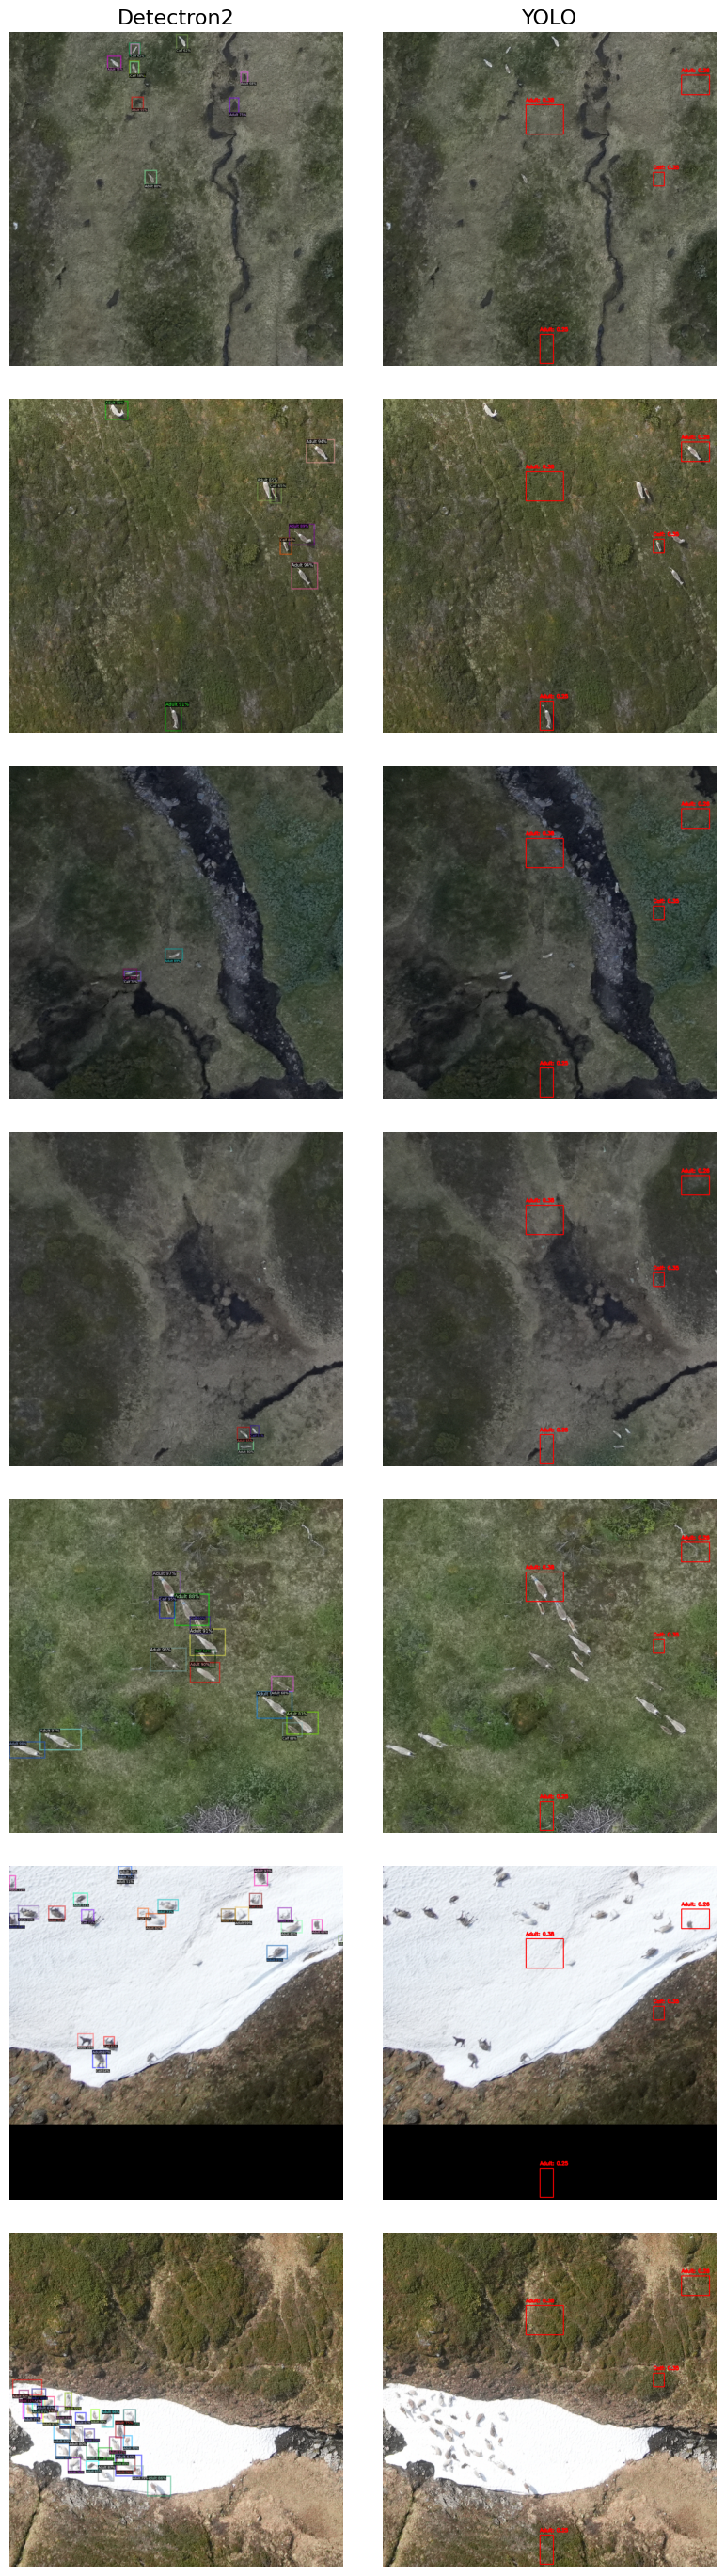

In [118]:
assert len(detectron2_output_imgs) == len(yolo_output_imgs) == len(img_paths)

# Adjust figure size to make the images larger
fig, ax = plt.subplots(
    len(img_paths), 2, figsize=(10, 5 * len(img_paths))
)  # Increase height

# Reduce space between images
fig.subplots_adjust(hspace=0.1, wspace=0.05)

ax[0, 0].set_title("Detectron2", fontsize=16)
ax[0, 1].set_title("YOLO", fontsize=16)

for i, (detectron2_output_img, yolo_output_img) in enumerate(
    zip(detectron2_output_imgs, yolo_output_imgs)
):
    # for some reason the channels are weird?
    ax[i, 0].imshow(detectron2_output_img[:, :, ::-1])
    ax[i, 0].axis("off")

    ax[i, 1].imshow(yolo_output_img)
    ax[i, 1].axis("off")

plt.savefig("detectron2_yolo_comparison.png")
